# A3 - Segmentação de Clientes de Varejo

---

**Unidade Curricular (UC):** Inteligência Artificial"

**Orientadores:** Prof. Joberto Martins e Prof. Arthur Kronbauer  

### Equipe Desenvolvedora
| Nome | Registro Acadêmico (RA) |
| :--- | :--- |
| Bianca de Oliveira Meneses | 1272319042 |
| Duilio do Nascimento Brandão | 12724216242 |
| Edioelson Júnior A. B. Teixeira | 1272318423 |
| Fillype da Silva Araujo| 12724145904 |
| João Paulo Souza Fontes | 12724113272 |
| Lucas Gaspar Vieira | 12724136365 |

---

### Objetivo do Projeto
Desenvolver um sistema baseado em aprendizado de máquina não supervisionado para segmentar clientes de um varejo de acordo com seus comportamentos e características demográficas. O objetivo é apoiar estratégias de negócios e campanhas direcionadas através da identificação de padrões ocultos nos dados.

### Metodologia e Modelagem
O projeto está estruturado nas seguintes etapas:
1. **Análise Exploratória de Dados (EDA):** Análise bivariada, identificação de *outliers* e estudo das distribuições das variáveis para compreender o perfil base dos clientes.
2. **Clusterização:**
    * **K-Means:** Particionamento focado nas distâncias médias.
   * **DBSCAN:** Agrupamento baseado em densidade espacial para lidar com formatos de clusters irregulares e ruídos.
3. **Métricas e Visualização:** Avaliação da qualidade da segmentação utilizando métricas de validação e técnicas de visualização de dados.

### Base de Dados
* **Conjunto de dados:** [Mall Customers Dataset](https://www.kaggle.com/datasets/shwetabh123/mall-customers)
* **Origem:** Kaggle
* **Descrição:** Dados contendo informações demográficas e comportamentais de clientes de uma empresa de varejo, incluindo pontuação de gastos e renda anual.

---

## Introdução e Objetivo do Projeto

Este notebook apresenta uma solução prática de Inteligência Artificial voltada para a segmentação de clientes de varejo.

Objetivo: A aplicação utiliza técnicas de Aprendizado de Máquina Não Supervisionado para extrair inteligência acionável a partir do dataset Mall Customers. Através dos algoritmos K-Means e DBSCAN, o sistema automatiza a identificação de padrões ocultos de comportamento. A finalidade deste código é agrupar os clientes de forma lógica para permitir:

- Personalização: Campanhas direcionadas a perfis específicos.
- Otimização: Foco em clientes de alto valor e redução de desperdício de recursos.
- Estratégia: Fornecer uma base de dados sólida para a tomada de decisões de negócio.

## Descrição e Dicionário de Dados

O conjunto de dados selecionado possui um formato tabular e é composto por atributos demográficos e comportamentais. Compreender a natureza de cada variável é um passo fundamental antes de iniciarmos qualquer etapa de pré-processamento ou modelagem.

Abaixo, detalhamos as *features* (colunas) presentes no *Mall Customers Dataset*:

| Atributo | Tipo de Dado | Descrição |
| :--------------------------- | :------------------- | :----------------------------------------------------------------------------------------- |
| **`CustomerID`** | Numérico| Identificador único atribuído a cada cliente.|
| **`Gender`** | Categórico (Nominal) | Gênero do cliente (ex: *Male*, *Female*). |
| **`Age`** | Numérico (Discreto)  | Idade do cliente em anos.|
| **`Annual Income (k$)`**     | Numérico (Contínuo)  | Renda anual estimada do cliente.                          |
| **`Spending Score (1-100)`** | Numérico (Discreto)  | Pontuação de 1 a 100 atribuída pela empresa com base no histórico de compras e fidelidade. |


## Ecossistema Tecnológico e Bibliotecas

Para garantir a reprodutibilidade, manipulação eficiente e modelagem estatística dos dados dentro do ambiente Google Colab, o projeto foi desenvolvido utilizando a linguagem Python e seu ecossistema nativo para Ciência de Dados.

As seguintes bibliotecas foram utilizadas para a implementação do pipeline:

* **[`pandas`](https://pandas.pydata.org/):** Utilizada para a ingestão, limpeza, manipulação e estruturação do conjunto de dados em formato de *DataFrames*.
* **[`numpy`](https://numpy.org/):** Responsável pelo suporte a vetores e matrizes multidimensionais, além de fornecer funções matemáticas de alta performance essenciais para os cálculos internos dos algoritmos de agrupamento.
* **[`matplotlib`](https://matplotlib.org/):** Biblioteca base de visualização de dados, empregada na construção dos gráficos da Análise Exploratória (EDA) e na plotagem geométrica dos *clusters* gerados.
* **[`scikit-learn (sklearn)`](https://scikit-learn.org/stable/):** O núcleo de inteligência do projeto. Fornece os submódulos necessários para:
  * O pré-processamento e escalonamento dos dados (essencial para modelos baseados em distância);
  * A execução dos algoritmos de aprendizado não supervisionado (`KMeans` e `DBSCAN`);
  * O cálculo das métricas de validação e qualidade da segmentação.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

## Ingestão de Dados e Inspeção Estrutural

Nesta etapa, realizamos a carga do conjunto de dados para o ambiente de desenvolvimento e iniciamos a verificação da sua integridade. O objetivo é executar uma auditoria inicial para garantir que não existam anomalias estruturais que possam enviesar ou comprometer os algoritmos de agrupamento.

A célula de código a seguir executa as seguintes rotinas:
* **Carga e Visualização:** Importação do arquivo `.csv` e amostragem do *DataFrame*.
* **Análise de Dimensões:** Levantamento do volume total de registros (linhas e colunas) disponíveis.
* **Auditoria de Qualidade:** Rastreamento rigoroso de valores nulos e registros duplicados.
* **Tipagem de Variáveis:** Verificação das estruturas de dados inferidas pelo Pandas para cada coluna.

In [26]:
df_url = "https://raw.githubusercontent.com/edd-araujo/segmentacao-clientes-varejo/refs/heads/feat/dataset-eda/data/Mall_Customers.csv"
mall_customers_df = pd.read_csv(df_url)

print("\n---------------------------- MALL CUSTOMERS DATASET ORIGINAL ----------------------------\n")
display(mall_customers_df)

print(f"\n\nO DATASET ORIGINAL POSSUI {mall_customers_df.shape[0]} LINHAS E {mall_customers_df.shape[1]} COLUNAS.")

print("\n\nVALORES NULOS POR COLUNA:\n")
display(mall_customers_df.isnull().sum())

print(f"\n\nQUANTIDADE DE VALORES DUPLICADOS: {mall_customers_df.duplicated().sum()}")

print("\n\nINFORMAÇÕES GERAIS:\n")
mall_customers_df.info()


---------------------------- MALL CUSTOMERS DATASET ORIGINAL ----------------------------



,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18




O DATASET ORIGINAL POSSUI 200 LINHAS E 5 COLUNAS.


VALORES NULOS POR COLUNA:



,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0




QUANTIDADE DE VALORES DUPLICADOS: 0


INFORMAÇÕES GERAIS:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


## Estatística Descritiva e Seleção de Variáveis

Após validar a integridade estrutural da base, o passo seguinte da nossa Análise Exploratória (EDA) é compreender o comportamento matemático dos dados.

### Seleção de Variáveis para Modelagem

Embora a idade (`Age`) seja um fator demográfico interessante, para a etapa de clusterização não supervisionada, optamos por restringir o escopo do modelo a duas variáveis comportamentais chave:

1. **`Annual Income (k$)`** (Renda Anual)
2. **`Spending Score (1-100)`** (Pontuação de Gastos)

In [27]:
numeric_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
print("\nResumo estatístico (numérico):\n", mall_customers_df[numeric_cols].describe())


Resumo estatístico (numérico):
               Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000          200.000000              200.000000
mean    38.850000           60.560000               50.200000
std     13.969007           26.264721               25.823522
min     18.000000           15.000000                1.000000
25%     28.750000           41.500000               34.750000
50%     36.000000           61.500000               50.000000
75%     49.000000           78.000000               73.000000
max     70.000000          137.000000               99.000000


## Análise Exploratória (EDA): Perfil Demográfico

### Distribuição por Gênero
Antes de focarmos no comportamento financeiro, é essencial compreender a demografia básica da nossa base de clientes. O gráfico a seguir ilustra a contagem e a proporção entre os gêneros presentes no *dataset*.

**Decisão de Modelagem (Exclusão da variável `Gender`):**
Embora o gênero seja uma dimensão valiosa para a construção de *personas* no time de negócios e útil para visualização de dados (colorização de gráficos), optamos por **não incluí-lo** nas variáveis de treinamento dos algoritmos K-Means e DBSCAN.

* **Justificativa Matemática e Estrutural:** O algoritmo K-Means agrupa dados minimizando a variância e calculando distâncias contínuas entre os pontos. Variáveis categóricas nominais (como Male/Female) não possuem uma distância geométrica natural. Inserir essa variável no modelo exigiria transformações que aumentariam a dimensionalidade e a esparsidade, distorcendo o cálculo de distância espacial e diluindo a força das variáveis comportamentais que realmente importam (Renda e Pontuação).

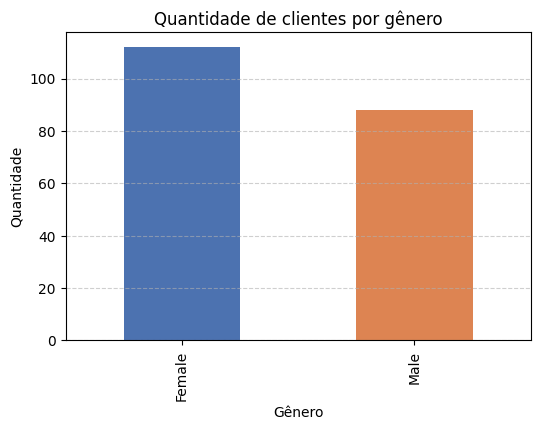

In [28]:
plt.figure(figsize=(6,4))
mall_customers_df["Gender"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.title("Quantidade de clientes por gênero")
plt.xlabel("Gênero")
plt.ylabel("Quantidade")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

### Distribuição das Variáveis (Histogramas)

Para compreender como os dados estão espalhados e identificar possíveis assimetrias (*skewness*), utilizamos histogramas para as variáveis numéricas. Essa análise é um pilar da estatística descritiva, pois revela a concentração do nosso público e o comportamento de cada atributo individualmente.

**Conclusões da Análise Visual:**
* **Idade (`Age`):** A distribuição apresenta uma leve assimetria à direita. Isso indica que a maior parte dos frequentadores do empreendimento é composta por adultos jovens e de meia-idade, com um declínio natural na frequência de clientes mais idosos.
* **Renda Anual (`Annual Income`):** Observa-se a formação de uma longa "cauda" à direita. A grande massa de clientes possui uma renda média centralizada (entre 50k e 80k dólares), enquanto uma minoria isolada compõe o grupo de altíssima renda.
* **Pontuação de Gastos (`Spending Score`):** É a variável que mais se aproxima de uma distribuição normal (formato de sino). A maioria absoluta dos clientes possui um comportamento de gasto mediano (pontuação em torno de 50), com as extremidades apresentando menor volume.

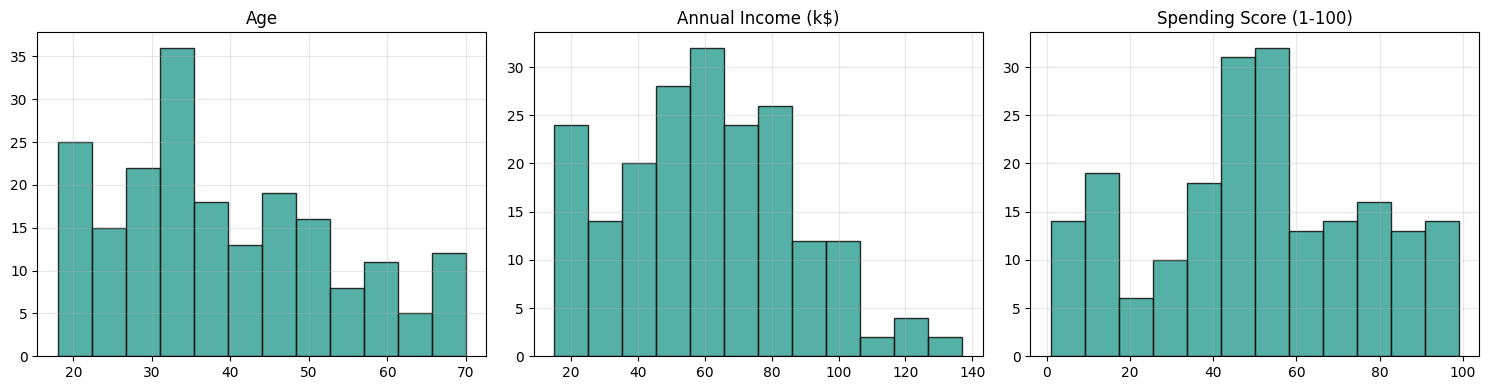

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, numeric_cols):
    ax.hist(mall_customers_df[col], bins=12, color="#2A9D8F", edgecolor="k", alpha=0.8)
    ax.set_title(col)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Análise de Valores Discrepantes (*Outliers*)

O diagrama de caixa (*Boxplot*) é uma ferramenta estatística crucial para visualizar a dispersão dos dados baseada em quartis e, principalmente, identificar outliers. Como os algoritmos de agrupamento baseados em distância (especialmente o **K-Means**) definem seus *clusters* através do cálculo de médias espaciais, eles são extremamente sensíveis a valores extremos, que podem distorcer a segmentação.

**Conclusões da Análise Visual:**
* **`Age` e `Spending Score`:** Não apresentam valores discrepantes. As distribuições estão bem contidas dentro dos limites interquartis.
* **`Annual Income`:** Apresenta um pequeno número de outliers na extremidade superior (indicando clientes com renda anual excepcionalmente alta, acima da faixa dos 130k dólares).

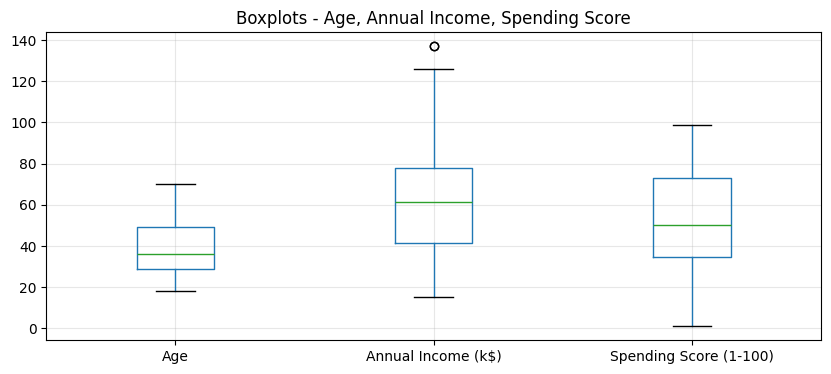

In [30]:
plt.figure(figsize=(10,4))
mall_customers_df[numeric_cols].boxplot()
plt.title("Boxplots - Age, Annual Income, Spending Score")
plt.grid(alpha=0.3)
plt.show()

### Análise Multivariada: Renda vs. Pontuação

Para aprofundar nossa compreensão do público, plotamos novamente as variáveis comportamentais chave (Renda e Pontuação de Gastos), mas agora adicionando o **Gênero** como uma terceira camada de informação visual através da colorização dos pontos.

**Conclusões da Análise:**
1. **Confirmação dos Clusters:** A formação de 5 grandes grupos de consumidores, que já havíamos notado anteriormente, permanece nítida. Temos claramente clientes de baixa/alta renda cruzando com baixos/altos gastos, além de um grupo massivo no centro.
2. **Distribuição de Gênero Homogênea:** Ao observar as cores, notamos que homens e mulheres estão distribuídos de maneira muito parecida por todos os 5 grupos. Não existe nenhum *cluster* que seja predominantemente masculino ou feminino.
3. **Validação da Modelagem:** Essa distribuição homogênea valida a nossa decisão técnica anterior de **excluir** o gênero do algoritmo de clusterização. Se incluíssemos o gênero, o modelo tentaria forçar separações que não existem no comportamento financeiro real, prejudicando a qualidade da segmentação.

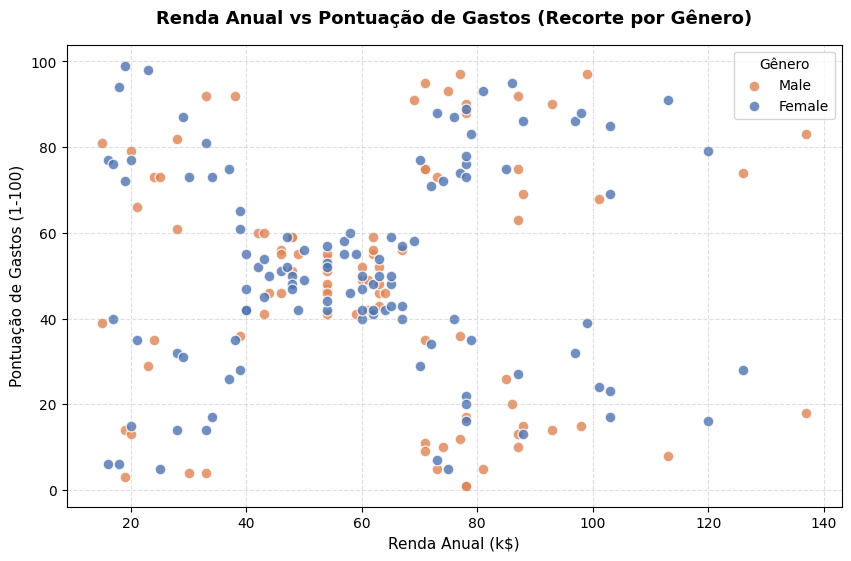

In [31]:
plt.figure(figsize=(10, 6))
colors = {"Male": "#DD8452", "Female": "#4C72B0"}

for gender, color in colors.items():

    subset = mall_customers_df[mall_customers_df['Gender'] == gender]

    plt.scatter(
        subset["Annual Income (k$)"],
        subset["Spending Score (1-100)"],
        c=color,
        alpha=0.8,
        s=60,
        edgecolors='white',
        label=gender
    )

plt.title("Renda Anual vs Pontuação de Gastos (Recorte por Gênero)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Renda Anual (k$)", fontsize=11)
plt.ylabel("Pontuação de Gastos (1-100)", fontsize=11)

plt.legend(title="Gênero")
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

### Análise de Correlação Linear (Matriz de Correlação)

Avaliamos o grau de dependência linear entre as variáveis numéricas através de uma Matriz de Correlação. Valores próximos a 1 ou -1 indicam forte correlação (positiva ou negativa), enquanto valores próximos a 0 indicam ausência de relação linear.

**Conclusões e Impacto na Modelagem:**
1. **Renda Anual vs. Pontuação de Gastos (Correlação ≈ 0.00):** A matriz comprova que não existe relação linear entre o quanto um cliente ganha e o quanto ele gasta. É exatamente essa **independência estatística** que justifica o uso de algoritmos de clusterização.
2. **Idade vs. Pontuação de Gastos (Correlação ≈ -0.33):** Existe uma correlação negativa fraca a moderada. Isso sugere uma leve tendência do público mais jovem possuir um comportamento de gasto mais agressivo (maior *Spending Score*), enquanto o público mais velho tende a ser mais conservador com os gastos.
3. **Ausência de Multicolinearidade:** Nenhuma das variáveis apresenta alta correlação com outra. Isso é o cenário ideal para o **K-Means**, garantindo que o cálculo da distância não sofra distorções por "peso duplo" de variáveis redundantes.

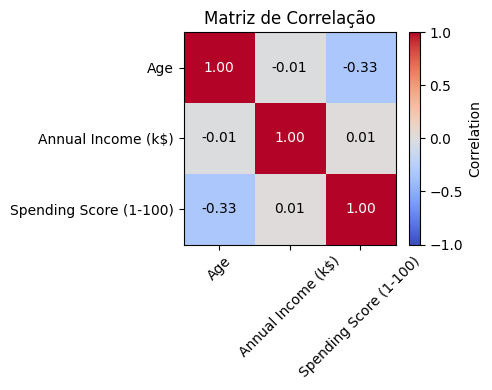

In [32]:
corr = mall_customers_df[numeric_cols].corr()

plt.figure(figsize=(5,4))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45)
plt.yticks(range(len(numeric_cols)), numeric_cols)

for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", color="w" if abs(corr.iloc[i,j])>0.5 else "k")

plt.title("Matriz de Correlação")
plt.tight_layout()

plt.show()

## Decisões tomadas e conclusões da EDA

1. **Exclusão de Atributos Identificadores e Categóricos:**
   * A coluna `CustomerID` será removida, pois atua apenas como chave primária e não carrega valor comportamental.
   * A coluna `Gender` não será utilizada no treinamento dos modelos.

2. **Seleção de Variáveis:**
   * O escopo do treinamento será restrito às variáveis **`Annual Income (k$)`** e **`Spending Score (1-100)`**.
   * *Nota: A variável `Age` (Idade) será omitida do cálculo de distância inicial para manter a coesão geométrica, mas poderá ser utilizada na etapa final para descrever a "persona" de cada cluster gerado.*

3. **Tratamento de outliers:**
   * Os *outliers* identificados na Renda Anual não são erros de coleta, mas sim representantes de um nicho legítimo de clientes de altíssima renda. Portanto, a decisão de negócio é **manter esses registros** na base.

4. **Escalonamento de Dados:**
   * Como a Renda Anual opera na casa dos milhares e o *Spending Score* na casa das dezenas, aplicaremos o **`StandardScaler`** antes de instanciar os modelos.

## Pré-processamento: Seleção e Escalonamento (*Scaling*)

Nesta fase, isolamos as duas variáveis comportamentais escolhidas (`Annual Income` e `Spending Score`) na matriz `X` e aplicamos o **`StandardScaler`** da biblioteca `scikit-learn`. Esse processo transforma os dados para que tenham média igual a zero e desvio padrão igual a um (z-score), garantindo que a diferença de grandeza entre milhares (renda) e dezenas (pontuação) não crie vieses matemáticos no cálculo de Distância Euclidiana dos algoritmos.

In [33]:
X = mall_customers_df[["Annual Income (k$)", "Spending Score (1-100)"]].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df=pd.DataFrame(X_scaled, columns=["Renda Anual Padronizada", "Pontuação de Gasto Padronizada"])

print("--- DADOS ORIGINAIS ---")
display(X.head())

print("\n--- DADOS ESCALONADOS / PADRONIZADOS ---")
display(X_scaled_df.head())


--- DADOS ORIGINAIS ---


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40



--- DADOS ESCALONADOS / PADRONIZADOS ---


,Renda Anual Padronizada,Pontuação de Gasto Padronizada
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


## Modelagem K-Means: Otimização do Hiperparâmetro (Método do Cotovelo)

O algoritmo *K-Means* exige que o número de agrupamentos (k$) seja definido previamente. Para encontrar o valor matemático ideal sem depender apenas de análises visuais, utilizamos a o **Método do Cotovelo**.

**Critério de Decisão:**
O número ideal de *clusters* encontra-se no ponto de inflexão da curva — o exato momento em que adicionar um novo grupo deixa de reduzir a inércia de forma drástica, formando o desenho de um "cotovelo".

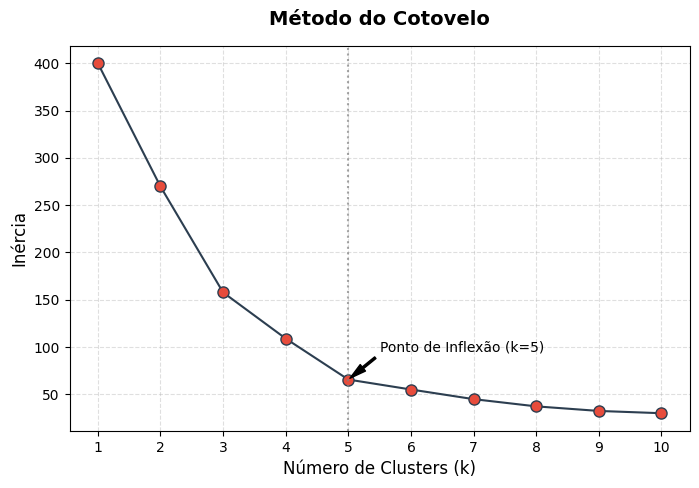

In [34]:

inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(
    k_range, inertias,
    marker="o",
    linestyle='-',
    color='#2c3e50',
    markersize=8,
    markerfacecolor='#e74c3c'
)

# Estilização do Gráfico
plt.title("Método do Cotovelo", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Número de Clusters (k)", fontsize=12)
plt.ylabel("Inércia", fontsize=12)
plt.xticks(k_range)

plt.axvline(x=5, color='gray', linestyle=':', alpha=0.7)
plt.annotate('Ponto de Inflexão (k=5)',
             xy=(5, inertias[4]),
             xytext=(5.5, inertias[4] + 30),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=6))

plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

## Validação da Otimização: Silhouette Score

Embora o Método do Cotovelo nos dê uma excelente estimativa visual (apontando para $k=5$), é uma boa prática validarmos essa escolha através de uma métrica quantitativa. Para isso, utilizamos o **Coeficiente de Silhueta** (*Silhouette Score*).

Utilizamos o Silhouette Score para validar as informações obtidas com o Método Cotovelo.

O *Silhouette Score* avalia a qualidade da segmentação medindo dois fatores simultaneamente:
1. **Coesão:** Quão próximo um ponto está dos outros pontos do seu próprio *cluster*.
2. **Separação:** Quão distante esse mesmo ponto está do *cluster* vizinho mais próximo.

In [35]:
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K = {k} | Silhouette Score = {score:.3f}")

K = 2 | Silhouette Score = 0.321
K = 3 | Silhouette Score = 0.467
K = 4 | Silhouette Score = 0.494
K = 5 | Silhouette Score = 0.555
K = 6 | Silhouette Score = 0.540
K = 7 | Silhouette Score = 0.528
K = 8 | Silhouette Score = 0.455
K = 9 | Silhouette Score = 0.457
K = 10 | Silhouette Score = 0.443


## Treinamento e Inferência: Modelo K-Means Final ($k=5$)

Com o número de agrupamentos rigorosamente validado tanto pelo Método do Cotovelo quanto pelo *Silhouette Score*, estabelecemos que **$k=5$** é a arquitetura ideal para este conjunto de dados.

Nesta etapa definitiva, instanciamos o modelo final e realizamos a rotulação de cada cliente em seu respectivo grupo. Criamos uma nova coluna chamada `Cluster_KMeans` no *DataFrame* original para armazenar o perfil de cada usuário.

Para validar o sucesso da segmentação, geramos o gráfico de dispersão final, mapeando as coordenadas espaciais dos **Centroides**.

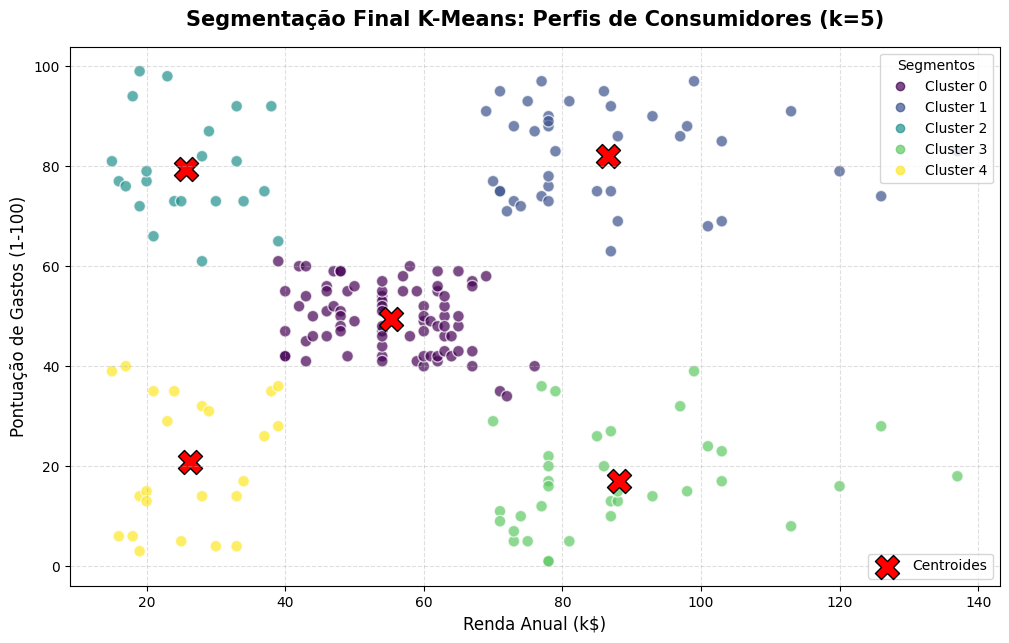


--- BASE DE DADOS ATUALIZADA (Primeiras 5 linhas) ---


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster_KMeans
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4



--- QUANTIDADE DE CLIENTES EM CADA GRUPO ---


,count
Cluster_KMeans,
0,81
1,39
2,22
3,35
4,23


In [36]:
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
mall_customers_df["Cluster_KMeans"] = kmeans_final.fit_predict(X_scaled)

centroides_escalonados = kmeans_final.cluster_centers_
centroides_originais = scaler.inverse_transform(centroides_escalonados)

plt.figure(figsize=(12, 7))

scatter = plt.scatter(
    mall_customers_df["Annual Income (k$)"],
    mall_customers_df["Spending Score (1-100)"],
    c=mall_customers_df["Cluster_KMeans"],
    cmap='viridis',
    alpha=0.7,
    s=70,
    edgecolors='white'
)

plt.scatter(
    centroides_originais[:, 0],
    centroides_originais[:, 1],
    s=300,
    c='red',
    marker='X',
    edgecolors='black',
    label='Centroides'
)

plt.title("Segmentação Final K-Means: Perfis de Consumidores (k=5)", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Renda Anual (k$)", fontsize=12)
plt.ylabel("Pontuação de Gastos (1-100)", fontsize=12)

label = scatter.legend_elements()[0]
clusters_name = [f"Cluster {i}" for i in range(5)]
legend1 = plt.legend(label, clusters_name, title="Segmentos", loc="upper right")
plt.gca().add_artist(legend1)

plt.legend(loc="lower right")

plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

print("\n--- BASE DE DADOS ATUALIZADA (Primeiras 5 linhas) ---")
display(mall_customers_df.head())

print("\n--- QUANTIDADE DE CLIENTES EM CADA GRUPO ---")
mall_customers_df["Cluster_KMeans"].value_counts().sort_index()


## Perfilamento de Clusters e Construção de Personas

A clusterização matemática por si só não gera valor de negócio. Para que a equipe de Marketing possa criar campanhas acionáveis, precisamos traduzir os grupos numéricos (0 a 4) em **Personas** compreensíveis.

Ao agruparmos os dados pela coluna `Cluster_KMeans` e calcularmos a média das variáveis financeiras, conseguimos extrair a identidade de cada segmento. Historicamente, a relação entre Renda Anual e Pontuação de Gastos neste conjunto de dados revela 5 perfis clássicos:

1. **Os Alvos (Ideais):** Alta Renda e Altos Gastos (O foco principal para produtos de luxo).
2. **Os Conservadores:** Alta Renda e Baixos Gastos (Têm dinheiro, mas são difíceis de converter).
3. **Os Impulsivos:** Baixa Renda e Altos Gastos (Consomem muito, mas exigem cuidado com limite de crédito).
4. **Os Econômicos:** Baixa Renda e Baixos Gastos (Focam em promoções e produtos essenciais).
5. **Os Medianeiros (Padrão):** Renda e Gastos medianos (O maior volume de clientes, sustenta o dia a dia da empresa).

In [37]:
cluster_profiles = mall_customers_df.groupby("Cluster_KMeans")[["Annual Income (k$)", "Spending Score (1-100)"]].mean().round(2)

cluster_profiles["Quantidade de Clientes"] = mall_customers_df.groupby("Cluster_KMeans").size()

cluster_profiles.rename(columns={
    "Annual Income (k$)": "Renda Anual Média (k$)",
    "Spending Score (1-100)": "Pontuação de Gasto Média"
}, inplace=True)

cluster_profiles.index.name = "Cluster (Grupo)"

print("--- PERFIL MÉDIO DOS SEGMENTOS (PERSONAS) ---")
display(cluster_profiles)

--- PERFIL MÉDIO DOS SEGMENTOS (PERSONAS) ---


,Renda Anual Média (k$),Pontuação de Gasto Média,Quantidade de Clientes
Cluster (Grupo),,,
0,55.30,49.52,81
1,86.54,82.13,39
2,25.73,79.36,22
3,88.20,17.11,35
4,26.30,20.91,23


## Segunda Abordagem: Agrupamento Espacial Baseado em Densidade (DBSCAN)

Para contrastar com os resultados obtidos pelo K-Means, implementamos o algoritmo **DBSCAN** (*Density-Based Spatial Clustering of Applications with Noise*). Esta escolha visa mitigar as limitações do K-Means frente a densidades variáveis e à presença de valores discrepantes.

**Características e Vantagens do DBSCAN:**
* **Formato Livre:** Ao contrário do K-Means, que assume uma geometria esférica para os grupos, o DBSCAN pode encontrar *clusters* de formatos arbitrários e irregulares.
* **Detecção Nativa de Ruído:** O algoritmo não força pontos isolados a entrarem em um grupo. Se um registro estiver em uma região de baixa densidade, ele é classificado como ruído (`label = -1`).
* **Não Requer K Prévio:** O número de agrupamentos é determinado dinamicamente pelo algoritmo.

**Hiperparâmetros Fundamentais:**
1. **`eps` ($\epsilon$ - Epsilon):** O raio da vizinhança ao redor de um ponto. Define a distância máxima para que dois registros sejam considerados vizinhos.
2. **`min_samples` (MinPts):** O número mínimo de pontos necessários dentro do raio $\epsilon$ para que uma região seja considerada densa o suficiente para iniciar um *cluster*.

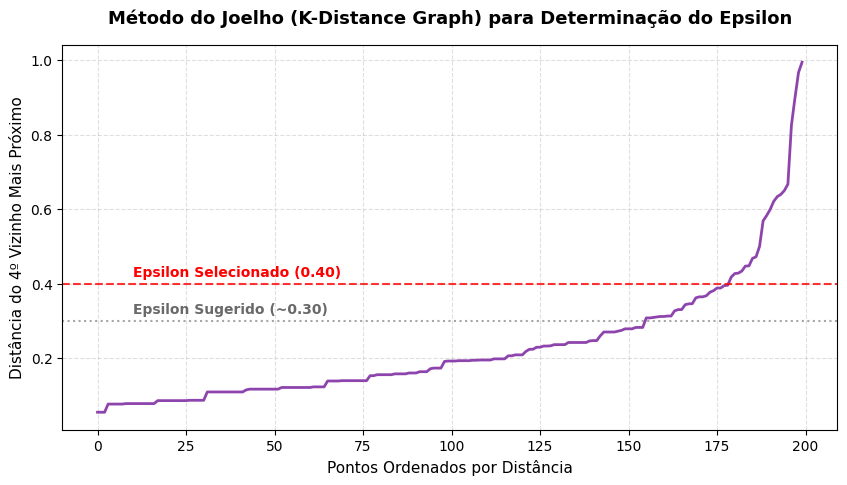

In [38]:
# Como temos 2 variáveis (Renda e Gasto), min_samples mínimo recomendado é 4.
min_samples_sugerido = 4

# n_neighbors é igual a min_samples para avaliar a densidade da vizinhança limite
vizinhos = NearestNeighbors(n_neighbors=min_samples_sugerido)
vizinhos_ajustados = vizinhos.fit(X_scaled)
distancias, indices = vizinhos_ajustados.kneighbors(X_scaled)

distancias_ordenadas = np.sort(distancias[:, min_samples_sugerido - 1], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distancias_ordenadas, color='#8e44ad', lw=2)

plt.title("Método do Joelho (K-Distance Graph) para Determinação do Epsilon", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Pontos Ordenados por Distância", fontsize=11)
plt.ylabel(f"Distância do {min_samples_sugerido}º Vizinho Mais Próximo", fontsize=11)

plt.axhline(y=0.30, color='gray', linestyle=':', alpha=0.7)
plt.text(10, 0.32, "Epsilon Sugerido (~0.30)", color='dimgray', fontsize=10, fontweight='bold')

plt.axhline(y=0.40, color='red', linestyle='--', alpha=0.8)
plt.text(10, 0.42, "Epsilon Selecionado (0.40)", color='red', fontsize=10, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

## Treinamento e Inferência: Modelo DBSCAN

Com os hiperparâmetros sugeridos pela análise do gráfico de K-Distância ($\epsilon \approx 0.40$ e $min\_samples = 5$), instanciamos o modelo **DBSCAN**.

Nesta etapa, o algoritmo irá varrer o espaço bidimensional escalonado à procura de regiões de alta densidade. Os pontos que não cumprirem os requisitos mínimos de vizinhança serão classificados nativamente como **Ruído/Outliers** e receberão o rótulo `-1`. Os grupos densos encontrados receberão rótulos a partir de `0`.

O código abaixo executa o algoritmo, contabiliza os grupos identificados e gera a visualização espacial, destacando explicitamente os clientes que foram isolados como ruído.

--- 📊 ESTATÍSTICAS DO DBSCAN ---
Número de clusters densos detectados: 5
Número de clientes classificados como ruído (Outliers): 15



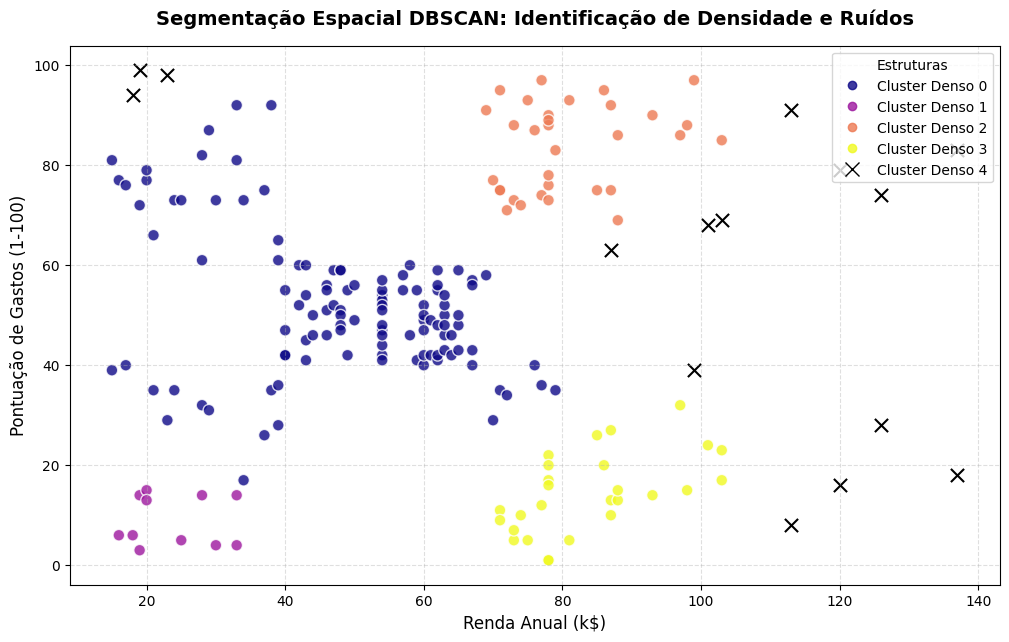

In [39]:
dbscan = DBSCAN(eps=0.40, min_samples=5)
mall_customers_df["Cluster_DBSCAN"] = dbscan.fit_predict(X_scaled)

labels_dbscan = mall_customers_df["Cluster_DBSCAN"]
n_clusters_ = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise_ = list(labels_dbscan).count(-1)

print(f"--- 📊 ESTATÍSTICAS DO DBSCAN ---")
print(f"Número de clusters densos detectados: {n_clusters_}")
print(f"Número de clientes classificados como ruído (Outliers): {n_noise_}\n")

plt.figure(figsize=(12, 7))

dados_validos = mall_customers_df[mall_customers_df["Cluster_DBSCAN"] != -1]
scatter_validos = plt.scatter(
    dados_validos["Annual Income (k$)"],
    dados_validos["Spending Score (1-100)"],
    c=dados_validos["Cluster_DBSCAN"],
    cmap="plasma",
    alpha=0.8,
    s=70,
    edgecolors="white",
    label="Clientes Agrupados"
)

ruidos = mall_customers_df[mall_customers_df["Cluster_DBSCAN"] == -1]
plt.scatter(
    ruidos["Annual Income (k$)"],
    ruidos["Spending Score (1-100)"],
    c="black",
    marker="x",
    s=90,
    label="Ruído / Outliers (-1)"
)

plt.title("Segmentação Espacial DBSCAN: Identificação de Densidade e Ruídos", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Renda Anual (k$)", fontsize=12)
plt.ylabel("Pontuação de Gastos (1-100)", fontsize=12)

legendas, _ = scatter_validos.legend_elements()
nomes_clusters = [f"Cluster Denso {i}" for i in range(n_clusters_)]
plt.legend(legendas + [plt.Line2D([0], [0], marker='x', color='black', linestyle='', markersize=10)],
           nomes_clusters + ["Ruídos (Outliers)"],
           title="Estruturas", loc="upper right")

plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

## Comparação Final: K-Means vs. DBSCAN

Nesta seção, consolidamos os resultados obtidos através das duas arquiteturas de segmentação (distância geométrica vs. densidade espacial), aplicadas às variáveis de Renda Anual e Pontuação de Gastos.

### 1. Formação e Contagem de Grupos
* **K-Means:** Foram identificados **5 clusters** rígidos (`k=5`).
* **DBSCAN:** O algoritmo dinamicamente **5 clusters densos**, isolando **15 clientes como ruído**.

### 2. Validação e Métricas de Desempenho
* **K-Means:** Apresentou um **Silhouette Score de 0.555**, indicando uma boa coesão interna e separação externa entre os quadrantes.
* **DBSCAN:** O Silhouette Score não foi calculado para este modelo, pois a presença do rótulo de ruído (`-1`) penaliza severamente o cálculo matemático da métrica, tornando a comparação injusta. A avaliação da qualidade do DBSCAN foi pautada na validação visual e na coerência de negócio do isolamento dos outliers.

### 3. Interpretabilidade de Negócios (Personas)
* **K-Means:** Possui altíssima facilidade de interpretação. Por gerar **Centroides** exatos, permite a extração de médias perfeitas para a criação de "Personas" de Marketing (ex: o cliente médio de Alta Renda/Alto Gasto).
* **DBSCAN:** A interpretação é mais complexa. Como os grupos assumem formas fluidas e não possuem um ponto central definido, definir uma persona "média" torna-se desafiador, exigindo uma análise mais focada nos limites daquele grupo do que no seu centro.

### 4. Tratamento de Anomalias (Ruídos e Outliers)
* **K-Means:** O modelo é **míope para outliers**. Ele não identificou os clientes de altíssima renda como pontos anômalos; ao invés disso, "esticou" as bordas dos seus clusters para engoli-los, o que distorce levemente a média de renda do grupo.
* **DBSCAN:** Demonstrou excelência ao classificar **15 clientes atípicos com o rótulo `-1`**. Isso revela para a equipe de negócios que esses clientes operam com um comportamento financeiro isolado e não devem receber as mesmas campanhas massificadas que os agrupamentos densos.

### Resumo das Vantagens e Desvantagens no Projeto

#### K-Means
* **Vantagens:** Simplicidade, alta interpretabilidade e facilidade na construção de personas claras devido à existência dos centroides.
* **Desvantagens:** Exige a validação prévia de `k` e é vulnerável a outliers, mascarando o comportamento de clientes fora da curva.

#### DBSCAN
* **Vantagens:** Identificação robusta de anomalias (ruídos) e determinação orgânica de grupos baseada na forma real dos dados, sem necessitar de `k` prévio.
* **Desvantagens:** Alta sensibilidade a hiperparâmetros (o ajuste fino do `eps` pelo gráfico K-Distância foi vital) e maior dificuldade técnica para descrever o perfil central do cliente agrupado.